<a href="https://colab.research.google.com/github/Seif-Sameh/LayoutLMv3-Invoice-eXtract/blob/main/Copy_of_LayoutLMv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'sroie-datasetv2:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F1569295%2F2916806%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20241012%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20241012T181013Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D1d615e4c523a0caff3d24666454736cea561b9b192327f50dbb9d994f51ab1fe7b28bf9e12581a01bd78deb55acf5cc01afca26d61538a2cca7c9774e7d8a0b46577ae788f6f0272720f96fcfc796c1af64e89b84a18d6758f2dfd184f98ca5eedc251e9f948b755837ea087191b2bf073847d20d99ec8e4b596b5295d9fc978dfaba260ef91feebc0f1b6eb14999e54e29039015d702fc97ff4140cf559918dee03332f0a9fb776f697a58eee025c80bb1cfce10420f65e4ac025a2a864293ed1dc6afcfea88c144c1cbfaa1ac69211973ceccb77575f9adab1e9324e68296b1fbefba5bbc608127ba128d77662de1bcf8042500007527f521ffb3fbe933c8c'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


# LayoutLMv3-Invoice Extract: Fine-Tuning for Invoice Understanding

**Project Idea:**  
This project focuses on fine-tuning the **LayoutLMv3** model on the SERIO dataset to improve invoice understanding and entity extraction. The primary goal is to enhance the model's ability to accurately interpret complex invoice layouts, identifying key information such as invoice numbers, dates, total amounts, and line items. By leveraging the LayoutLMv3 model's visual and textual learning capabilities, the project aims to achieve more efficient and accurate processing of invoices for real-world applications in financial management and automated data extraction.

**Objectives:**
- Fine-tune LayoutLMv3 on the SERIO dataset for better invoice understanding.
- Improve the model's ability to recognize key entities such as invoice numbers, dates, total amounts, and line items.
- Apply the model in real-world scenarios to automate invoice data extraction and financial management.

**Conclusion:**  
By enhancing the LayoutLMv3 model's ability to accurately interpret invoices, this project seeks to advance automated solutions for financial document processing, leading to more streamlined workflows in financial and administrative tasks.


## Required Libraries and Imports

The following libraries and modules are essential for data processing, model training, evaluation, and visualization. They include utilities for handling datasets, image transformations, tokenization, and metrics calculation. The LayoutLMv3 model and Trainer from Hugging Face’s `transformers` library are also imported to facilitate token classification tasks on structured documents like invoices.

- **os, glob, shutil**: For file handling and directory management.
- **PIL (Python Imaging Library)**: For image processing and rendering.
- **cv2 (OpenCV)**: For advanced image manipulation and visualization.
- **torch, torchvision**: For building and training deep learning models.
- **transformers**: To use the LayoutLMv3 model, tokenizers, and the Trainer class.
- **sklearn**: To calculate metrics such as accuracy, precision, recall, and F1 score.
- **matplotlib**: For visualizing images and bounding boxes.
- **tqdm**: To display progress bars during training.

In [ ]:
import os
import glob
import json
import random
from pathlib import Path
from difflib import SequenceMatcher
import shutil
from PIL import Image, ImageDraw, ImageFont
import cv2
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from IPython.display import display
import matplotlib
from matplotlib import pyplot, patches
from time import perf_counter
import random
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from transformers import LayoutLMv3Tokenizer
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from transformers import TrainingArguments, Trainer
from transformers import LayoutLMv3ForTokenClassification, AutoConfig
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np



### let's see one invoice to gain some insights

In [ ]:
sroie_folder_path = Path('/kaggle/input/sroie-datasetv2/SROIE2019')
example_file = Path('X51005365187.txt')

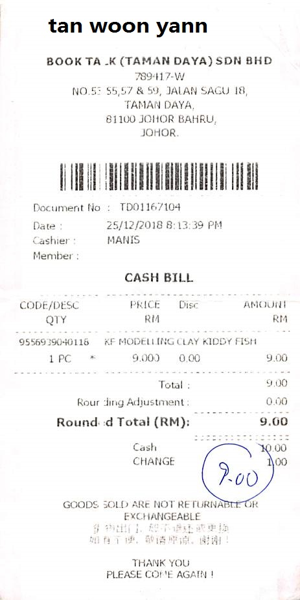

In [ ]:
image = Image.open("/kaggle/input/sroie-datasetv2/SROIE2019/train/img/X00016469612.jpg")
image = image.convert("RGB")
new_image = image.resize((300, 600))
new_image


## Data Prepocessing

## Reading Bounding Boxes and Words from Text Files

This function `read_bbox_and_words` reads bounding box coordinates and text from a given file and processes the data into a structured format. The text file is expected to contain comma-separated values where the first eight values represent the bounding box coordinates (in terms of four points: x0, y0, x1, y1, x2, y2, x3, y3) and the remaining values correspond to the associated text. The function splits these values, stores them in a list, and finally converts them into a Pandas DataFrame.

### Steps:
1. **File Reading and Parsing**: The function opens the specified file, processes each line, and extracts bounding box coordinates along with the corresponding text.
2. **Data Storage**: The parsed data is stored in a list and then converted into a DataFrame for easier handling and manipulation.
3. **Bounding Box Conversion**: The bounding box coordinates are explicitly converted into integers for future processing.
4. **Dropping Unnecessary Columns**: Some of the bounding box columns are dropped to simplify the data (e.g., `x1`, `y1`, `x3`, and `y3` are removed).
5. **Preview**: The function returns the processed DataFrame, and we display the first few rows of the file and the DataFrame to verify the result.

The `head()` command is used to show the first five lines from the input file and the first few rows of the resulting DataFrame.


In [ ]:
def read_bbox_and_words(path: Path):
  bbox_and_words_list = []

  with open(path, 'r', errors='ignore') as f:
    for line in f.read().splitlines():
      if len(line) == 0:
        continue

      split_lines = line.split(",")

      bbox = np.array(split_lines[0:8], dtype=np.int32)
      text = ",".join(split_lines[8:])

      # From the splited line we save (filename, [bounding box points], text line).
      # The filename will be useful in the future
      bbox_and_words_list.append([path.stem, *bbox, text])

  dataframe = pd.DataFrame(bbox_and_words_list, columns=['filename', 'x0', 'y0',
                                                         'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'line'])

  # Explicitly convert only the bounding box columns to integers
  bbox_columns = ['x0', 'y0','x1', 'y1', 'x2', 'y2', 'x3', 'y3']  # Adjust based on your actual columns
  dataframe[bbox_columns] = dataframe[bbox_columns].astype(np.int16)

  dataframe = dataframe.drop(columns=['x1', 'y1', 'x3', 'y3'])

  return dataframe
bbox_file_path = sroie_folder_path / "test/box" / example_file
print("== File content ==")
!head -n 5 "{bbox_file_path}"

bbox = read_bbox_and_words(path=bbox_file_path)
print("\n== Dataframe ==")
bbox.head(5)

== File content ==


/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


17,35,371,35,371,91,17,91,3-1707067
222,115,511,115,511,143,222,143,F&P PHARMACY
274,148,457,148,457,174,274,174,(002309592-P)
204,183,529,183,529,210,204,210,NO.20. GROUND FLOOR,
99,218,632,218,632,244,99,244,JALAN BS 10/6 TAMAN BUKIT SERDANG,

== Dataframe ==


,filename,x0,y0,x2,y2,line
0,X51005365187,17,35,371,91,3-1707067
1,X51005365187,222,115,511,143,F&P PHARMACY
2,X51005365187,274,148,457,174,(002309592-P)
3,X51005365187,204,183,529,210,"NO.20. GROUND FLOOR,"
4,X51005365187,99,218,632,244,"JALAN BS 10/6 TAMAN BUKIT SERDANG,"


### Read Entities from JSON:
This function reads invoice entities from a JSON file and returns them as a Pandas DataFrame.


In [ ]:
def read_entities(path: Path):
  with open(path, 'r') as f:
    data = json.load(f)

  dataframe = pd.DataFrame([data])
  return dataframe


# Example usage
entities_file_path = sroie_folder_path /  "test/entities" / example_file
print("== File content ==")
!head "{entities_file_path}"

entities = read_entities(path=entities_file_path)
print("\n\n== Dataframe ==")
entities

== File content ==


/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


{
    "company": "F&P PHARMACY",
    "date": "02/03/2018",
    "address": "NO.20. GROUND FLOOR, JALAN BS 10/6 TAMAN BUKIT SERDANG, SEKSYEN 10, 43300 SERI KEMBANGAN. SELANGOR DARUL EHSAN",
    "total": "31.90"
}

== Dataframe ==


,company,date,address,total
0,F&P PHARMACY,02/03/2018,"NO.20. GROUND FLOOR, JALAN BS 10/6 TAMAN BUKIT...",31.90


### Assign Line Label:
This function assigns a label to a line of text based on its similarity to entity names from a DataFrame, returning the matching entity type or "O" for no match.


In [ ]:
def assign_line_label(line: str, entities: pd.DataFrame):
    line_set = line.replace(",", "").strip().split()
    for i, column in enumerate(entities):
        entity_set =  entities.iloc[0, i].replace(",", "").strip().split()


        matches_count = 0
        for l in line_set:
            if any(SequenceMatcher(a=l, b=b).ratio() > 0.8 for b in entity_set):
                matches_count += 1

            if (column.upper() == 'ADDRESS' and (matches_count / len(line_set)) >= 0.5) or \
               matches_count == len(entity_set):
                return column.upper()

    return "O"


line = bbox.loc[1,"line"]
label = assign_line_label(line, entities)
print("Line:", line)
print("Assigned label:", label)

Line: F&P PHARMACY
Assigned label: COMPANY


### Assign Labels:
This function assigns labels to words based on their bounding box dimensions and the presence of entities, ensuring unique assignments for critical fields like TOTAL and DATE while preventing conflicts.


In [ ]:
def assign_labels(words: pd.DataFrame, entities: pd.DataFrame):
    max_area = {"TOTAL": (0, -1), "DATE": (0, -1)}  # Value, index
    already_labeled = {"TOTAL": False,
                       "DATE": False,
                       "ADDRESS": False,
                       "COMPANY": False,
                       "O": False
    }

    # Go through every line in $words and assign it a label
    labels = []
    for i, line in enumerate(words['line']):
        label = assign_line_label(line, entities)

        already_labeled[label] = True
        if (label == "ADDRESS" and already_labeled["TOTAL"]) or \
           (label == "COMPANY" and (already_labeled["DATE"] or already_labeled["TOTAL"])):
            label = "O"
         # Assign to the largest bounding box
        if label in ["TOTAL", "DATE"]:
            x0_loc = words.columns.get_loc("x0")
            bbox = words.iloc[i, x0_loc:x0_loc+4].to_list()
            area = (bbox[2] - bbox[0]) + (bbox[3] - bbox[1])

            if max_area[label][0] < area:
                max_area[label] = (area, i)

            label = "O"

        labels.append(label)

    labels[max_area["DATE"][1]] = "DATE"
    labels[max_area["TOTAL"][1]] = "TOTAL"

    words["label"] = labels
    return words


# Example usage
bbox_labeled = assign_labels(bbox, entities)
bbox_labeled.head(15)

,filename,x0,y0,x2,y2,line,label
0,X51005365187,17,35,371,91,3-1707067,O
1,X51005365187,222,115,511,143,F&P PHARMACY,COMPANY
2,X51005365187,274,148,457,174,(002309592-P),O
3,X51005365187,204,183,529,210,"NO.20. GROUND FLOOR,",ADDRESS
4,X51005365187,99,218,632,244,"JALAN BS 10/6 TAMAN BUKIT SERDANG,",ADDRESS
5,X51005365187,111,250,623,275,"SEKSYEN 10, 43300 SERI KEMBANGAN,",ADDRESS
6,X51005365187,186,284,538,308,SELANGOR DARUL EHSAN,ADDRESS
7,X51005365187,251,316,484,339,TEL 03-89599823,O
8,X51005365187,182,351,346,378,GST REG NO,O
9,X51005365187,274,387,461,409,TAX INVOICE,O


In [ ]:
bbox_labeled.columns

Index(['filename', 'x0', 'y0', 'x2', 'y2', 'line', 'label'], dtype='object')

### Split Line:
This function splits a line into individual words while maintaining the same bounding box coordinates for each word, as the research indicates that they share the same context.


In [ ]:
def split_line(line: pd.Series) -> list:
    """
    Splits a line into words and updates bounding box coordinates for each word.

    Parameters:
        line (pd.Series): A pandas Series with 'x0', 'x2', and 'line' columns.

    Returns:
        list: A list of lists where each sublist contains updated values for the line.
    """
    # Ensure the line has the necessary columns
    if not {'x0', 'x2', 'line'}.issubset(line.index):
        raise ValueError("The line must contain 'x0', 'x2', and 'line' columns.")

    # Extract current bounding box information
    x0 = line['x0']
    x2 = line['x2']
    bbox_width = line['x2'] - line['x0']  # Example width, adjust as needed
    line_str = line['line']

    words = line_str.split()
    new_lines = []

    # Iterate through each word and calculate new bounding box coordinates
    for index, word in enumerate(words):

        # Create a new Series for the updated line
        line_copy = line.copy()
        line_copy['x0'] = x0
        line_copy['x2'] = x2
        line_copy['line'] = word

        # Append the updated line to the new_lines list
        new_lines.append(line_copy.to_list())

        # Update x0 for the next word
    return new_lines



# Example usage
new_lines = split_line(bbox_labeled.loc[1])
print("Original row:")
display(bbox_labeled.loc[1:1,:])

print("Splitted row:")
pd.DataFrame(new_lines, columns=bbox_labeled.columns)

Original row:


,filename,x0,y0,x2,y2,line,label
1,X51005365187,222,115,511,143,F&P PHARMACY,COMPANY


Splitted row:


,filename,x0,y0,x2,y2,line,label
0,X51005365187,222,115,511,143,F&P,COMPANY
1,X51005365187,222,115,511,143,PHARMACY,COMPANY


In [ ]:
def dataset_creator(folder: Path):
  bbox_folder = folder / 'box'
  entities_folder = folder / 'entities'
  img_folder = folder / 'img'

  # Sort by filename so that when zipping them together
  # we don't get some other file (just in case)
  entities_files = sorted(entities_folder.glob("*.txt"))
  bbox_files = sorted(bbox_folder.glob("*.txt"))
  img_files = sorted(img_folder.glob("*.jpg"))

  data = []

  print("Reading dataset:")
  for bbox_file, entities_file, img_file in tqdm(zip(bbox_files, entities_files, img_files), total=len(bbox_files)):
    # Read the files
    bbox = read_bbox_and_words(bbox_file)
    entities = read_entities(entities_file)
    image = Image.open(img_file)

    # Assign labels to lines in bbox using entities
    bbox_labeled = assign_labels(bbox, entities)
    del bbox

    # Split lines into separate tokens
    new_bbox_l = []
    for index, row in bbox_labeled.iterrows():
      new_bbox_l += split_line(row)
    new_bbox = pd.DataFrame(new_bbox_l, columns=bbox_labeled.columns)
    new_bbox[['x0', 'y0', 'x2', 'y2']] = new_bbox[['x0', 'y0', 'x2', 'y2']].astype(np.int16)

    del bbox_labeled


    # Do another label assignment to keep the labeling more precise
    for index, row in new_bbox.iterrows():
      label = row['label']

      if label != "O":
        entity_values = entities.iloc[0, entities.columns.get_loc(label.lower())]
        entity_set = entity_values.split()

        if any(SequenceMatcher(a=row['line'], b=b).ratio() > 0.7 for b in entity_set):
            label = "S-" + label
        else:
            label = "O"

      new_bbox.at[index, 'label'] = label

    width, height = image.size

    data.append([new_bbox, width, height])

  return data

In [ ]:
dataset_train = dataset_creator(sroie_folder_path / 'train')
dataset_test = dataset_creator(sroie_folder_path / 'test')

Reading dataset:


100%|██████████| 626/626 [00:50<00:00, 12.42it/s]


Reading dataset:


100%|██████████| 347/347 [00:27<00:00, 12.61it/s]


### train-test split

In [ ]:
random.seed(42)
random.shuffle(dataset_test)
dataset_val = dataset_test[174:]
dataset_test = dataset_test[:174]
print(len(dataset_val))
print (len(dataset_test))

173
174


In [ ]:
dataset_train[0][0]["x0"]

0      72
1      72
2      72
3      50
4      50
     ... 
80    163
81    163
82    163
83    163
84    412
Name: x0, Length: 85, dtype: int16

In [ ]:
class InvoiceDataset(Dataset):
    def __init__(self, invoice_list, tokenizer, image_folder_path):
        self.invoice_list = invoice_list
        self.tokenizer = tokenizer
        self.image_folder_path = image_folder_path
        self.label_map = {
            "S-COMPANY": 0,
            "S-ADDRESS": 1,
            "S-DATE": 2,
            "S-TOTAL": 3,
            "O": 4,  # For 'Other'
        }
        self.max_length = 512
        self.transform = transforms.Compose([
            transforms.Resize((384, 384)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.invoice_list)

    def __getitem__(self, idx):
        invoice_data = self.invoice_list[idx]
        word_df = invoice_data[0]
        image_width = invoice_data[1]
        image_height = invoice_data[2]
        image_path = word_df["filename"].iloc[0]

        words = []
        bboxes = []
        labels = []

        # Load and preprocess the image
        image_path = f"{self.image_folder_path}/{image_path}.jpg"
        try:
            image = Image.open(image_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None
        image = self.transform(image)

        for _, word_data in word_df.iterrows():
            word = word_data['line']
            label = word_data['label']
            bbox = [
                word_data['x0'],
                word_data['y0'],
                word_data['x2'],
                word_data['y2']
            ]

            # Normalize the bounding boxes
            normalized_bbox = [
                bbox[0]* 1000/ image_width,
                bbox[1]*1000 / image_height,
                bbox[2]* 1000/ image_width,
                bbox[3]*1000 / image_height
            ]

            words.append(word)
            bboxes.append(normalized_bbox)
            labels.append(label)

        # Tokenize the words with bounding boxes
        tokens = self.tokenizer(
            words,
            boxes=bboxes,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            is_split_into_words=True,
            return_tensors="pt",
            return_attention_mask=True
        )

        # Convert labels to numerical format
        labels = [self.label_map.get(label, self.label_map["O"]) for label in word_df['label'].tolist()]

        # Pad labels to max length with -100
        padded_labels = labels + [-100] * (self.max_length - len(labels))  # Use -100 for padding
        labels_tensor = torch.tensor(padded_labels, dtype=torch.long)

        bbox_tensor = tokens['bbox'].squeeze(0)
        if bbox_tensor.size(0) < self.max_length:
            padding = torch.zeros((self.max_length - bbox_tensor.size(0), 4), dtype=torch.float32)  # Pad with zeros
            bbox_tensor = torch.cat([bbox_tensor, padding], dim=0)

        # Convert everything to long
        input_ids_tensor = tokens['input_ids'].squeeze(0).long()
        attention_mask_tensor = tokens['attention_mask'].squeeze(0).long()

        return  {
            'input_ids': input_ids_tensor,
            'attention_mask': attention_mask_tensor,
            'bbox': bbox_tensor.to(torch.long),
            'labels': labels_tensor,
            'pixel_values': image
        }

# Initialize tokenizer
tokenizer = LayoutLMv3Tokenizer.from_pretrained("mp-02/layoutlmv3-large-cord2")

# Create your dataset
image_folder_path = '/kaggle/input/sroie-datasetv2/SROIE2019/train/img'
dataset = InvoiceDataset(dataset_train, tokenizer=tokenizer, image_folder_path=image_folder_path)
val_set = InvoiceDataset(dataset_val, tokenizer=tokenizer, image_folder_path="/kaggle/input/sroie-datasetv2/SROIE2019/test/img")


### Ensure Tensor Shapes
It is crucial to verify that the shapes of all tensors are correct before proceeding with model training. This includes ensuring that input tensors match the expected dimensions of the model and that target tensors (labels) align with the input tensor shapes. Proper shape management helps prevent runtime errors and ensures the model learns effectively.


In [ ]:
print(dataset[0]["input_ids"].shape)
print(dataset[0]["attention_mask"].shape)
print(dataset[0]["bbox"].shape)
print(dataset[0]["labels"].shape)
print(dataset[0]["pixel_values"].shape)

torch.Size([512])
torch.Size([512])
torch.Size([512, 4])
torch.Size([512])
torch.Size([3, 384, 384])


In [ ]:
dataset[0]["bbox"]

tensor([[  0,   0,   0,   0],
        [155,  24, 704,  63],
        [155,  24, 704,  63],
        ...,
        [  0,   0,   0,   0],
        [  0,   0,   0,   0],
        [  0,   0,   0,   0]])

In [ ]:
import warnings
from transformers import logging as transformers_logging

warnings.filterwarnings("ignore")
transformers_logging.set_verbosity_error()


In [ ]:
!pip install wandb

In [ ]:
import wandb
wandb.login(key="43683e6439b3f848199c0e333e5ffdc8c1695604")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

## Training

In this section, we define the training parameters and initialize the `Trainer` for fine-tuning the LayoutLMv3 model on the SERIO dataset. The training arguments include evaluation strategies, logging settings, and learning rate specifications. The model is configured to freeze the first few layers to retain pre-trained weights while allowing the rest to be trainable. The `compute_metrics` function is utilized to evaluate the model's performance during training.

The following code initializes the model and the training process.


In [ ]:
def compute_metrics(pred):

    #Extract logits (predictions) and labels
    logits = pred.predictions
    labels = pred.label_ids

    #Convert logits to predicted class indices
    predictions = np.argmax(logits, axis=-1)

    #Remove padding labels
    mask = labels != -100
    labels = labels[mask]
    predictions = predictions[mask]

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


from transformers import TrainingArguments

# Define TrainingArguments
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    save_strategy='epoch',
    logging_dir='./logs',
    logging_steps=100,
    num_train_epochs=15,
    learning_rate=5e-5,
    report_to='wandb',
    run_name='layoutlmv3-training',
    # Dataloader-related parameters
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True
)

# Initialize the model
model = LayoutLMv3ForTokenClassification.from_pretrained(
    "mp-02/layoutlmv3-large-cord2",
    num_labels=5,
    attention_probs_dropout_prob=0.2,
    hidden_dropout_prob=0.2
)
config = AutoConfig.from_pretrained("mp-02/layoutlmv3-large-cord2", num_labels=5)
print(f"Number of parameters: {model.num_parameters()}")
print(config)

# Freeze the first 8 layers
for idx, param in enumerate(model.parameters()):
    if idx < 8:
        param.requires_grad = False
    else:
        param.requires_grad = True

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=val_set,
    compute_metrics=compute_metrics
)

Number of parameters: 356010501
LayoutLMv3Config {
  "_name_or_path": "mp-02/layoutlmv3-large-cord2",
  "architectures": [
    "LayoutLMv3ForTokenClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "coordinate_size": 171,
  "eos_token_id": 2,
  "has_relative_attention_bias": true,
  "has_spatial_attention_bias": true,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4"
  },
  "initializer_range": 0.02,
  "input_size": 224,
  "intermediate_size": 4096,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4
  },
  "layer_norm_eps": 1e-05,
  "max_2d_position_embeddings": 1024,
  "max_position_embeddings": 514,
  "max_rel_2d_pos": 256,
  "max_rel_pos": 128,
  "model_type": "layoutlmv3",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_

In [ ]:
trainer.train()

RuntimeError: The size of tensor a (577) must match the size of tensor b (197) at non-singleton dimension 1

## Best Model Selection

The best model is the one with the highest F1 score on the validation set. This metric provides a balance between precision and recall, making it a suitable choice for evaluating model performance in tasks where class distribution may be imbalanced.


In [ ]:
model = LayoutLMv3ForTokenClassification.from_pretrained('/kaggle/working/results/checkpoint-4695')

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=val_set,
    compute_metrics=compute_metrics
)

training_evaluation = trainer.evaluate(eval_dataset= dataset)
val_evaluation = trainer.evaluate(eval_dataset= val_set)
print(training_evaluation)

{'eval_loss': 0.04256788268685341, 'eval_model_preparation_time': 0.0104, 'eval_accuracy': 0.9864345904130405, 'eval_precision': 0.9855319730599795, 'eval_recall': 0.9864345904130405, 'eval_f1': 0.9854226859311861, 'eval_runtime': 93.4232, 'eval_samples_per_second': 6.701, 'eval_steps_per_second': 3.35}
{'eval_loss': 0.26512494683265686, 'eval_model_preparation_time': 0.0104, 'eval_accuracy': 0.9555134637043105, 'eval_precision': 0.9494416499876704, 'eval_recall': 0.9555134637043105, 'eval_f1': 0.9522288790376395, 'eval_runtime': 25.6644, 'eval_samples_per_second': 6.741, 'eval_steps_per_second': 3.39}
{'eval_loss': 0.04256788268685341, 'eval_model_preparation_time': 0.0104, 'eval_accuracy': 0.9864345904130405, 'eval_precision': 0.9855319730599795, 'eval_recall': 0.9864345904130405, 'eval_f1': 0.9854226859311861, 'eval_runtime': 93.4232, 'eval_samples_per_second': 6.701, 'eval_steps_per_second': 3.35}


In [ ]:
print(val_evaluation)

{'eval_loss': 0.26512494683265686, 'eval_model_preparation_time': 0.0104, 'eval_accuracy': 0.9555134637043105, 'eval_precision': 0.9494416499876704, 'eval_recall': 0.9555134637043105, 'eval_f1': 0.9522288790376395, 'eval_runtime': 25.6644, 'eval_samples_per_second': 6.741, 'eval_steps_per_second': 3.39}


## Evaluating Model performance on the Test Set

In this section, we will evaluate the performance of our trained model on the test set.

In [ ]:
test_set = InvoiceDataset(dataset_test, tokenizer=tokenizer, image_folder_path="/kaggle/input/sroie-datasetv2/SROIE2019/test/img")
test_evaluation = trainer.evaluate(eval_dataset= test_set)
print(test_evaluation)

{'eval_loss': 0.25944486260414124, 'eval_model_preparation_time': 0.0104, 'eval_accuracy': 0.9560750446694462, 'eval_precision': 0.949383555224238, 'eval_recall': 0.9560750446694462, 'eval_f1': 0.9525934639787529, 'eval_runtime': 26.7355, 'eval_samples_per_second': 6.508, 'eval_steps_per_second': 3.254}
{'eval_loss': 0.25944486260414124, 'eval_model_preparation_time': 0.0104, 'eval_accuracy': 0.9560750446694462, 'eval_precision': 0.949383555224238, 'eval_recall': 0.9560750446694462, 'eval_f1': 0.9525934639787529, 'eval_runtime': 26.7355, 'eval_samples_per_second': 6.508, 'eval_steps_per_second': 3.254}


## Output Production Phase

In this phase of the pipeline, we aim to produce the output in JSON file format. This is crucial for integrating the model's predictions with other applications or systems that require structured data.

### Steps to Produce JSON Output:

1. **Extract Predictions**: After evaluating the model on the validation/test dataset, extract the relevant predictions (e.g., bounding boxes, labels, company name, date, address, and total).
  
2. **Structure the Data**: Organize the extracted data into a dictionary format. Each entry should correspond to a specific field that we want to include in the JSON output.

3. **Convert to JSON**: Use Python's built-in `json` module to convert the structured data into JSON format.

4. **Save the JSON File**: Write the JSON data to a file for further use or analysis.

This phase is typically referred to as the **Output Generation Phase** in the machine learning pipeline, where we focus on converting model predictions into a consumable format.


### I will use on observation from test set to extract the output as json file a

In [ ]:
observation = {k: v for k, v in test_set[0].items() if k != 'labels'} # remove labels

with torch.no_grad():
    outputs = model(input_ids=observation['input_ids'], attention_mask=observation['attention_mask'], bbox=observation['bbox'], pixel_values= observation['images'])


TypeError: LayoutLMv3ForTokenClassification.forward() got an unexpected keyword argument 'images'

In [ ]:
{k: v for k, v in test_set[0].items() if k != 'labels'}

{'input_ids': tensor([    0, 34835,   108,   104,  8748,   597, 44583, 22570,   208,    73,
           387,   974,  2022,   612,    12,   791,    36,   530,   863,   134,
            43,  8228,     4,   291,    12,   250,   134,     6,   344,  2118,
          1889, 11643,   401,    73,   246,     6,   229,  3721, 14629,   344,
          2547,   250,     6,   204,  5352, 21817,  2118,  1862,   344,  2547,
           250,   208,  3721,  9298,  3411,   211,     4,   717,     4,   255,
          3721,    73,  5944,  1000,  4832,    12, 15171,   111,   262,  4652,
         35723,  2881,   255,  3721,    35,  2663,  2036, 25208, 34923,    36,
           534,  4014,  4576,  4832, 12096,  2890,  1749,  4697,  2881,    43,
         16667,  1000,  2808, 32956,  9292, 18638,  8228,  4832,   530,   863,
         11343,  4280,   996,  2517,   211,  8625,    35,  1922,    73,  4197,
            73,  1360,   158,    35,  4540,   230, 13246, 35875,    35, 18514,
          1092,  4283, 46824,  4832,  2